In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!python -m pip install pyyaml==5.1

!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 9.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-g3ilfdz9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-g3ilfdz9
  Resolved https://github.com/facebookresearch/detectron2.git to commit d38d7161247e64276d4c44d9d0605291e80bd969
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.

In [3]:
import detectron2

from detectron2.utils.logger import setup_logger
setup_logger()

from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog

import numpy as np
import torch, os, json, cv2, random
from google.colab.patches import cv2_imshow

In [ ]:
#https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip

In [45]:
ballonData_path = '/content/balloon'

In [35]:
!wget https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip -O /content/balloon_dataset.zip
!unzip /content/balloon_dataset.zip -d /content/

--2025-08-25 18:30:04--  https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/107595270/737339e2-2b83-11e8-856a-188034eb3468?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-08-25T19%3A11%3A42Z&rscd=attachment%3B+filename%3Dballoon_dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-08-25T18%3A11%3A36Z&ske=2025-08-25T19%3A11%3A42Z&sks=b&skv=2018-11-09&sig=PISUlxjDgN8GJvE%2F3hJKVGlmxFQd%2B9gQ5tJjLrkkzhc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1NjE0NjkwNCwibmJmIjoxNzU2MTQ2NjA0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHV

In [58]:
from detectron2.data import DatasetCatalog

for d in ["train", "val"]:
    MetadataCatalog.get("/content/balloon" + d).set(thing_classes=["balloon"])

balloon_metadata = MetadataCatalog.get("balloon_train")

In [63]:
from detectron2.structures import BoxMode
import os
import json
import cv2
import numpy as np

def get_balloon_dicts(img_dir, dataset_path):
  json_file = os.path.join(dataset_path, "via_region_data.json")
  with open(json_file) as f:
    imgs_anns = json.load(f)

  dataset_dicts = []
  for idx, v in enumerate(imgs_anns.values()):
    record = {}

    filename = os.path.join(img_dir, v["filename"])
    height, width = cv2.imread(filename).shape[:2]

    record["file_name"] = filename
    record["image_id"] = idx
    record["height"] = height
    record["width"] = width

    annos = v["regions"]
    objs = []
    for _, anno in annos.items():
      assert not anno["region_attributes"]
      anno = anno["shape_attributes"]
      px = anno["all_points_x"]
      py = anno["all_points_y"]
      poly = [(x + 0.5, y + 0.5) for x, y in zip(px, py)]
      poly = [p for x in poly for p in x]

      obj = {
          "bbox": [np.min(px), np.min(py), np.max(px), np.max(py)],
          "bbox_mode": BoxMode.XYXY_ABS,
          "segmentation": [poly],
          "category_id": 0,
      }
      objs.append(obj)

      record["annotations"] = objs
      dataset_dicts.append(record)
    return dataset_dicts

In [57]:
from detectron2.data import DatasetCatalog

for d in ["train", "val"]:
    MetadataCatalog.get("/content/balloon" + d).set(thing_classes=["balloon"])

balloon_metadata = MetadataCatalog.get("balloon_train")

Loaded 1 images with annotations.


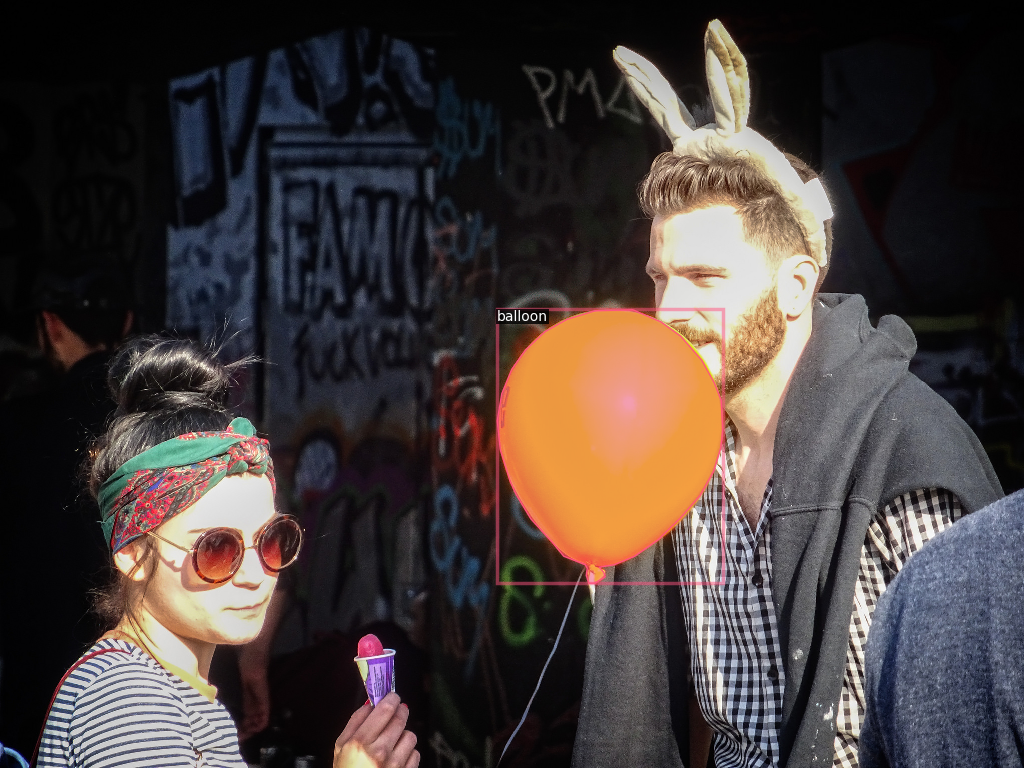

In [72]:
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.data import DatasetCatalog # Although not directly used in this cell, good practice to include if related to dataset handling
from detectron2.structures import BoxMode # Needed for get_balloon_dicts
import os
import json
import cv2
import random
import numpy as np
from google.colab.patches import cv2_imshow


# Define the get_balloon_dicts function within this cell
def get_balloon_dicts(img_dir, dataset_path):
  json_file = os.path.join(dataset_path, "via_region_data.json")
  with open(json_file) as f:
    imgs_anns = json.load(f)

  dataset_dicts = []
  for idx, v in enumerate(imgs_anns.values()):
    record = {}

    filename = os.path.join(img_dir, v["filename"])
    height, width = cv2.imread(filename).shape[:2]

    record["file_name"] = filename
    record["image_id"] = idx
    record["height"] = height
    record["width"] = width

    annos = v["regions"]
    objs = []
    for _, anno in annos.items():
      assert not anno["region_attributes"]
      anno = anno["shape_attributes"]
      px = anno["all_points_x"]
      py = anno["all_points_y"]
      poly = [(x + 0.5, y + 0.5) for x, y in zip(px, py)]
      poly = [p for x in poly for p in x]

      obj = {
          "bbox": [np.min(px), np.min(py), np.max(px), np.max(py)],
          "bbox_mode": BoxMode.XYXY_ABS,
          "segmentation": [poly],
          "category_id": 0,
      }
      objs.append(obj)

      record["annotations"] = objs
      dataset_dicts.append(record)
    return dataset_dicts

# Define ballonData_path if not defined
try:
    ballonData_path
except NameError:
    ballonData_path = '/content/balloon' # Assuming the dataset was extracted to /content/balloon


dataset_dicts = get_balloon_dicts(os.path.join(ballonData_path, "train"), os.path.join(ballonData_path, "train")) # Corrected dataset_path

print(f"Loaded {len(dataset_dicts)} images with annotations.")

if not dataset_dicts:
    print("No dataset dictionaries were loaded. Please check the file path and contents.")
else:
    for d in random.sample(dataset_dicts, min(3, len(dataset_dicts))):
        img = cv2.imread(d["file_name"])
        visualizer = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("balloon_train"), scale=0.5)
        out = visualizer.draw_dataset_dict(d)
        cv2_imshow(out.get_image()[:, :, ::-1])